In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


In [ ]:
train_dir = "/content/EuroSAT_full_split/train"
val_dir = "/content/EuroSAT_full_split/val"


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Input preprocessed dataset path
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
split_base = "/content/EuroSAT_full_split"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")

# Clean old split if exists (optional)
if os.path.exists(split_base):
    shutil.rmtree(split_base)

# Create folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Get class names
classes = sorted(os.listdir(source_dir))

# Split images per class
for cls in tqdm(classes, desc="Splitting Classes"):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Split 80% train, 20% val
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ All images split and saved to:", split_base)


Splitting Classes: 100%|██████████| 10/10 [12:55<00:00, 77.52s/it]

✅ All images split and saved to: /content/EuroSAT_full_split


In [ ]:
import os

print(os.listdir("/content/EuroSAT_full_split"))  # Should show: ['train', 'val']
print(os.listdir("/content/EuroSAT_full_split/train"))  # Should show class folders like 'Forest', etc.


['train', 'val']
['PermanentCrop', 'River', 'HerbaceousVegetation', 'Forest', 'AnnualCrop', 'Highway', 'Pasture', 'Residential', 'SeaLake', 'Industrial']


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 21721 images belonging to 10 classes.
Found 5432 images belonging to 10 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [ ]:
# Image size and batch size
img_size = (224, 224)
batch_size = 32

# Image data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Only rescaling for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 21721 images belonging to 10 classes.
Found 5432 images belonging to 10 classes.


In [ ]:
# Load base ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained layers

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

# Combine base and head
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
checkpoint = ModelCheckpoint("best_resnet_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    callbacks=[checkpoint, early_stop]
)


679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1579 - loss: 2.2365
Epoch 1: val_accuracy improved from -inf to 0.24908, saving model to best_resnet_model.h5


679/679 ━━━━━━━━━━━━━━━━━━━━ 5033s 7s/step - accuracy: 0.1579 - loss: 2.2364 - val_accuracy: 0.2491 - val_loss: 1.9950


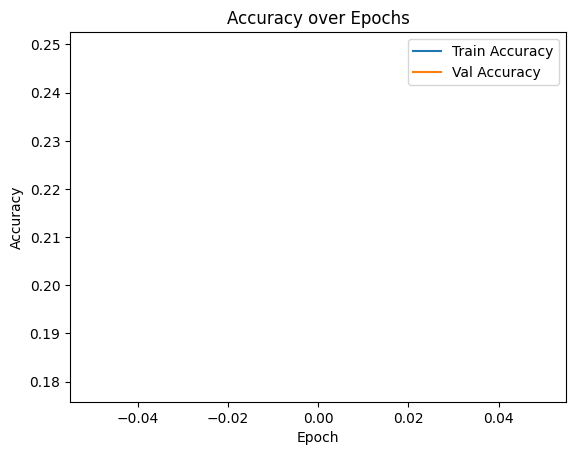

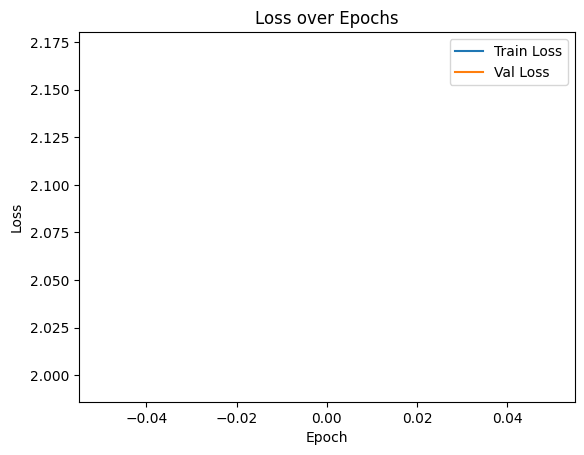

In [ ]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()
